# Calcolo Punteggi Amenity per Immobili

Questo notebook calcola i punteggi amenity per gli immobili utilizzando dati POI spaziali.

## Import Required Libraries

Importa le librerie necessarie come json, os, numpy, pandas, sklearn.neighbors e sys.

In [1]:
import json
import os
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree
import sys

## Define Constants

Definisce le costanti come EARTH_RADIUS_KM e MAX_DISTANCE_M.

In [2]:
# Costanti
EARTH_RADIUS_KM = 6371.0
MAX_DISTANCE_M = 5000  # Distanza massima per considerare POI

In [3]:
# Definizione dei parametri S (Service Base) e U (Urban Multiplier)
# Basato sulla formula: f(x) = e^(-(x / (S * U))^3)

# Parametri S (Service Base) per tipologia di servizio (in km)
SERVICE_BASE = {
    'breve': 0.340,   # 300m threshold in Zona B
    'medio': 0.680,   # 600m threshold in Zona B
    'lungo': 1.360    # 1200m threshold in Zona B
}

# Parametri U (Urban Multiplier) per zona
URBAN_MULTIPLIER = {
    'B': 1.0,   # Centrale - alta pedonabilità
    'C': 1.5,   # Semicentrale - mix auto/piedi
    'D': 2.5,   # Periferica - prevalenza trasporto/auto
    'E': 4.0    # Suburbana - dipendenza auto
}

# Definizione delle classi per le amenity
amenity_to_class = {}

# Sanità
breve_sanita = ["pharmacy", "defibrillator"]
medio_sanita = ["doctor", "dentist", "clinic", "physiotherapist", "veterinary", "optometrist", "psychotherapist", "physiotherapist-osteopathy", "alternative"]
lungo_sanita = ["hospital", "laboratory", "dialysis", "hospice", "rehabilitation", "audiologist", "medical_supply", "blood_donation"]

for a in breve_sanita:
    amenity_to_class[a] = 'breve'
for a in medio_sanita:
    amenity_to_class[a] = 'medio'
for a in lungo_sanita:
    amenity_to_class[a] = 'lungo'

# Mobilità
breve_mobilita = ["bus_stop", "tram_stop", "bicycle_parking", "taxi", "subway_entrance", "charging_station"]
medio_mobilita = ["parking", "bicycle_rental", "car_sharing"]
lungo_mobilita = ["station", "car_rental"]

for a in breve_mobilita:
    amenity_to_class[a] = 'breve'
for a in medio_mobilita:
    amenity_to_class[a] = 'medio'
for a in lungo_mobilita:
    amenity_to_class[a] = 'lungo'

# Verde
breve_verde = ["playground", "garden", "grass", "park"]
medio_verde = ["recreation_ground", "scrub"]
lungo_verde = ["forest", "nature_reserve", "wood", "allotments"]

for a in breve_verde:
    amenity_to_class[a] = 'breve'
for a in medio_verde:
    amenity_to_class[a] = 'medio'
for a in lungo_verde:
    amenity_to_class[a] = 'lungo'

# Sport
breve_sport = ["fitness_centre", "pitch"]
medio_sport = ["swimming_pool", "sports_centre", "bowling_alley"]
lungo_sport = ["stadium", "golf_course", "water_park", "ice_rink"]

for a in breve_sport:
    amenity_to_class[a] = 'breve'
for a in medio_sport:
    amenity_to_class[a] = 'medio'
for a in lungo_sport:
    amenity_to_class[a] = 'lungo'

# Commerciale
breve_commerciale = ["supermarket", "bakery", "greengrocer", "newsagent", "kiosk", "convenience", "tobacco", "laundry", "hairdresser", "butcher", "pastry", "ice_cream", "deli", "stationery", "grocery", "vending_machine"]
medio_commerciale = ["clothes", "shoes", "florist", "hardware", "chemist", "pet", "books", "gift", "optician", "beauty", "mobile_phone", "jewelry", "toys", "electronics", "bicycle", "travel_agency", "dry_cleaning", "photo", "video", "confectionery", "alcohol", "wine", "cheese", "dairy", "seafood", "pasta", "spices", "tea", "coffee", "coffee_roasting", "herbalist", "tattoo", "massage", "spa", "copyshop", "shoe_repair", "tailor", "sewing", "fabric", "bag", "fashion_accessories", "cosmetics", "variety_store", "second_hand", "video_games", "sports", "nutrition_supplements", "perfumery", "watches", "baby_goods", "houseware", "repair", "mobile_phone_accessories", "party", "religion", "locksmith", "art", "frame", "ticket", "food", "general", "pet_grooming"]
lungo_commerciale = ["mall", "department_store", "furniture", "car", "car_repair", "car_parts", "motorcycle", "motorcycle_repair", "funeral_directors", "kitchen", "bathroom_furnishing", "bed", "lighting", "curtain", "window_blind", "carpet", "flooring", "tiles", "paint", "doityourself", "garden_centre", "wholesale", "trade", "auction_house", "antiques", "glaziery", "weapons", "hunting", "fishing", "scuba_diving", "boat", "water_sports", "army", "outpost", "erotic", "bookmaker", "money_lender", "pawnbroker", "gold_buyer", "telecommunication", "computer", "printer_ink", "cartridges", "hifi", "musical_instrument", "appliance", "hvac", "security", "tool_hire", "charity", "craft", "leather", "pottery", "model", "hobby", "games", "anime", "wigs", "hearing_aids", "rice", "fair_trade", "printing", "plaques", "scooter", "tyres", "caravan", "brewing_supplies", "country_store", "military_surplus", "hairdresser_supply", "vacant", "gas", "outdoor", "radiotechnics"]

for a in breve_commerciale:
    amenity_to_class[a] = 'breve'
for a in medio_commerciale:
    amenity_to_class[a] = 'medio'
for a in lungo_commerciale:
    amenity_to_class[a] = 'lungo'

# Educazione
breve_educazione = ["kindergarten", "school", "community_centre"]
medio_educazione = ["library", "music_school", "driving_school"]
lungo_educazione = ["university", "college", "museum", "research_institute"]

for a in breve_educazione:
    amenity_to_class[a] = 'breve'
for a in medio_educazione:
    amenity_to_class[a] = 'medio'
for a in lungo_educazione:
    amenity_to_class[a] = 'lungo'

## Load Immobili Data

Carica il dataset degli immobili da un file Parquet utilizzando pandas.

In [4]:
def load_immobili_data():
    """Carica il dataset degli immobili."""
    # Aggiungi la root del progetto al path
    sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('__file__'), '../../')))
    from app.core.config import DATASET_FULL
    immobili_path = os.path.join(os.path.dirname('__file__'), '../../', DATASET_FULL)
    immobili_path = os.path.abspath(immobili_path)
    print(f"Caricando immobili da {immobili_path}")
    df = pd.read_parquet(immobili_path)
    print(f"Caricato {len(df)} immobili")
    return df

## Load POIs Data

Carica i dati POI categorizzati da un file JSON.

In [5]:
def load_pois_data():
    """Carica i POI categorizzati."""
    pois_path = os.path.join(os.path.dirname('__file__'), '../01_pois/pois_by_category.json')
    print(f"Caricando POI da {pois_path}")
    with open(pois_path, 'r', encoding='utf-8') as f:
        pois_by_category = json.load(f)
    print(f"Caricato POI per {len(pois_by_category)} categorie")
    return pois_by_category

## Build Spatial Index

Costruisce un indice spaziale utilizzando BallTree per tutti i POI.

In [6]:
def build_spatial_index(pois_by_category):
    """Costruisce l'indice spaziale per tutti i POI."""
    all_pois = []
    for category, amenities in pois_by_category.items():
        for amenity, pois in amenities.items():
            for poi in pois:
                all_pois.append({
                    'category': category,
                    'amenity': amenity,
                    'lat': poi['lat'],
                    'lon': poi['lon']
                })

    if not all_pois:
        raise ValueError("Nessun POI trovato")

    # Coordinate in radianti per BallTree
    coords = np.array([[np.radians(p['lat']), np.radians(p['lon'])] for p in all_pois])
    tree = BallTree(coords, metric='haversine')

    print(f"Costruito indice spaziale con {len(all_pois)} POI")
    return tree, all_pois

In [7]:
# Debug: verifica range coordinate POI
immobili_df = load_immobili_data()
pois_by_category = load_pois_data()
tree, all_pois = build_spatial_index(pois_by_category)

# Verifica range POI
poi_lats = [p['lat'] for p in all_pois]
poi_lons = [p['lon'] for p in all_pois]
print(f"POI - Latitudine: min={min(poi_lats):.6f}, max={max(poi_lats):.6f}")
print(f"POI - Longitudine: min={min(poi_lons):.6f}, max={max(poi_lons):.6f}")

# Verifica range immobili
immobili_lats = immobili_df['latitudine'].values
immobili_lons = immobili_df['longitudine'].values
print(f"\nImmobili - Latitudine: min={immobili_lats.min():.6f}, max={immobili_lats.max():.6f}")
print(f"Immobili - Longitudine: min={immobili_lons.min():.6f}, max={immobili_lons.max():.6f}")

# Verifica se ci sono valori anomali
print(f"\nNumero totale immobili: {len(immobili_df)}")
print(f"Numero totale POI: {len(all_pois)}")

Caricando immobili da /Users/marcodeluca/Downloads/real-estate-ai/backend/data/FOLDER_META/immobili_with_meta_and_ape_full_cleaned.parquet
Caricato 14877 immobili
Caricando POI da ../01_pois/pois_by_category.json
Caricato POI per 6 categorie
Costruito indice spaziale con 24230 POI
POI - Latitudine: min=44.980974, max=45.257315
POI - Longitudine: min=7.551414, max=7.930744

Immobili - Latitudine: min=44.838515, max=45.150860
Immobili - Longitudine: min=7.107835, max=7.771379

Numero totale immobili: 14877
Numero totale POI: 24230


## Calculate Amenity Scores

Calcola i punteggi amenity per ogni immobile utilizzando query spaziali e decadimento esponenziale.

In [8]:
def calculate_amenity_scores(immobili_df, tree, all_pois, output_path, all_amenities, pois_by_category):
    """Calcola i punteggi amenity per ogni immobile e ogni amenity usando la formula f(x) = e^(-(x / (S * U))^3)."""
    
    # Zona di default se non presente nel dataset (C - Semicentrale)
    DEFAULT_ZONE = 'C'
    
    # Crea mapping amenity -> category
    amenity_to_category = {}
    for category, amenities in pois_by_category.items():
        for amenity in amenities.keys():
            amenity_to_category[amenity] = category
    
    max_dist_rad = MAX_DISTANCE_M / 1000 / EARTH_RADIUS_KM

    min_dist = float('inf')
    max_dist_val = -float('inf')

    # Dizionari per accumulare i dati per amenity
    # IMPORTANTE: Inizializza con tutti gli immobili e tutte le amenity
    amenity_data = {amenity: {'immobile_ids': [], 'scores': []} for amenity in all_amenities}
    
    # Ottieni tutti gli ID immobili per assicurarci che siano tutti presenti
    all_immobile_ids = immobili_df['id'].tolist()
    print(f"Totale immobili da processare: {len(all_immobile_ids)}")
    print(f"Totale amenity da calcolare: {len(all_amenities)}")

    for idx in range(len(immobili_df)):
        immobile = immobili_df.iloc[idx]
        immobile_id = immobile['id']
        immobile_lat = immobile['latitudine']
        immobile_lon = immobile['longitudine']
        
        # Determina la zona dell'immobile (se disponibile nel dataset)
        if 'zona' in immobile and immobile['zona'] in URBAN_MULTIPLIER:
            zona = immobile['zona']
        else:
            zona = DEFAULT_ZONE
        
        U = URBAN_MULTIPLIER[zona]

        # Query POI entro MAX_DISTANCE_M con distanze
        query_point = np.array([[np.radians(immobile_lat), np.radians(immobile_lon)]])
        indices_list, distances_list = tree.query_radius(query_point, r=max_dist_rad, return_distance=True)
        indices = np.array(indices_list[0], dtype=int)
        distances = np.array(distances_list[0], dtype=float)
        distances_km = distances * EARTH_RADIUS_KM

        # IMPORTANTE: Inizializza lo score a 0 per TUTTE le amenity
        amenity_scores = {amenity: 0.0 for amenity in all_amenities}

        if indices.size > 0:
            min_dist = min(min_dist, distances.min())
            max_dist_val = max(max_dist_val, distances.max())

            for i, poi_idx in enumerate(indices):
                poi = all_pois[poi_idx]
                amenity = poi['amenity']
                
                # Determina la classe del servizio
                classe = amenity_to_class.get(amenity, 'lungo')
                S = SERVICE_BASE[classe]
                
                # Calcola lo score usando la nuova formula: f(x) = e^(-(x / (S * U))^3)
                # x in km, S in km
                x = distances_km[i]
                score_contrib = np.exp(-((x / (S * U)) ** 3))
                
                amenity_scores[amenity] += score_contrib

        # IMPORTANTE: Accumula i dati per TUTTE le amenity, anche quelle con score 0
        for amenity in all_amenities:
            amenity_data[amenity]['immobile_ids'].append(immobile_id)
            amenity_data[amenity]['scores'].append(amenity_scores[amenity])

        if (idx + 1) % 100 == 0:
            print(f"Elaborati {idx + 1}/{len(immobili_df)} immobili")

    # Salva risultati in Parquet
    print("Salvataggio risultati in Parquet...")
    
    # Verifica che tutte le amenity abbiano lo stesso numero di immobili
    for amenity in all_amenities:
        if len(amenity_data[amenity]['immobile_ids']) != len(all_immobile_ids):
            print(f"WARNING: amenity {amenity} ha {len(amenity_data[amenity]['immobile_ids'])} immobili invece di {len(all_immobile_ids)}")
    
    # Crea DataFrame con tutti i dati
    rows = []
    for amenity in all_amenities:
        immobile_ids = amenity_data[amenity]['immobile_ids']
        scores = amenity_data[amenity]['scores']
        category = amenity_to_category.get(amenity, 'unknown')
        
        for i in range(len(immobile_ids)):
            rows.append({
                'immobile_id': int(immobile_ids[i]),
                'amenity': amenity,
                'category': category,
                'score': scores[i]
            })
        
        print(f"  Completata amenity: {amenity} ({len(immobile_ids)} immobili)")
    
    # Crea DataFrame e salva in Parquet
    result_df = pd.DataFrame(rows)
    result_df.to_parquet(output_path, index=False)

    print(f"\nSalvataggio completato!")
    print(f"Totale righe scritte: {len(result_df)}")
    print(f"Verifica: {len(all_amenities)} amenity × {len(all_immobile_ids)} immobili = {len(all_amenities) * len(all_immobile_ids)} righe")
    
    return None, min_dist, max_dist_val

## Calculate Category Averages and Percentiles

Calcola la media degli score per categoria POI e calcola i percentili rispetto agli altri immobili nella stessa categoria.

In [9]:
def calculate_category_avg_scores_and_percentiles(input_parquet_path, output_parquet_path):
    """
    Calcola la media degli score per categoria POI per ogni immobile,
    e calcola il percentile dell'immobile rispetto agli altri immobili nella stessa categoria.
    
    Args:
        input_parquet_path: Path al Parquet con immobile_id, amenity, category, score
        output_parquet_path: Path al Parquet di output con immobile_id, category, avg_score, percentile
    """
    print(f"\n=== Calcolo media score per categoria e percentili ===")
    print(f"Input: {input_parquet_path}")
    print(f"Output: {output_parquet_path}")
    
    # Leggi il Parquet con gli score per amenity (include già la colonna category)
    df = pd.read_parquet(input_parquet_path)
    print(f"Caricati {len(df)} record dal Parquet")
    print(f"Amenity uniche: {df['amenity'].nunique()}")
    print(f"Immobili unici: {df['immobile_id'].nunique()}")
    print(f"Categorie presenti: {sorted(df['category'].unique())}")
    
    # Verifica che tutte le righe abbiano una categoria
    missing_categories = df[df['category'].isna()]
    if len(missing_categories) > 0:
        print(f"WARNING: {len(missing_categories)} righe senza categoria")
    
    # Calcola la media degli score per (immobile, category)
    print("\nCalcolo media score per categoria...")
    category_avg = df.groupby(['immobile_id', 'category'])['score'].mean().reset_index()
    category_avg.columns = ['immobile_id', 'category', 'avg_score']
    
    print(f"Calcolate {len(category_avg)} medie (immobile, categoria)")
    
    # Calcola percentili per categoria
    print("\nCalcolo percentili per categoria...")
    from scipy.stats import percentileofscore
    
    def calculate_percentile(row, category_scores):
        """Calcola il percentile di uno score rispetto agli altri nella stessa categoria."""
        category = row['category']
        score = row['avg_score']
        scores_in_category = category_scores[category]
        return percentileofscore(scores_in_category, score, kind='rank')
    
    # Raggruppa gli score per categoria per il calcolo dei percentili
    category_scores = {}
    for category in category_avg['category'].unique():
        category_scores[category] = category_avg[category_avg['category'] == category]['avg_score'].values
    
    # Calcola percentili
    category_avg['percentile'] = category_avg.apply(lambda row: calculate_percentile(row, category_scores), axis=1)
    
    # Salva risultati in Parquet
    category_avg.to_parquet(output_parquet_path, index=False)
    print(f"\nSalvato {output_parquet_path}")
    print(f"Totale righe: {len(category_avg)}")
    
    # Statistiche per categoria
    print("\nStatistiche per categoria:")
    for category in sorted(category_avg['category'].unique()):
        cat_data = category_avg[category_avg['category'] == category]
        print(f"  {category}:")
        print(f"    - Immobili: {len(cat_data)}")
        print(f"    - Avg score: min={cat_data['avg_score'].min():.4f}, max={cat_data['avg_score'].max():.4f}, mean={cat_data['avg_score'].mean():.4f}")
        print(f"    - Percentile: min={cat_data['percentile'].min():.2f}, max={cat_data['percentile'].max():.2f}")
    
    return category_avg

## Save Results

Salva i risultati in un file CSV ed esegue il processo principale.

In [10]:
def main(subset_size=None):
    print("=== FASE 1: Calcolo score per amenity ===")

    # Carica dati
    immobili_df = load_immobili_data()

    # Usa subset se richiesto
    if subset_size:
        immobili_df = immobili_df.head(subset_size)
        print(f"DEBUG: Usando solo {len(immobili_df)} immobili per test")
        output_path_amenity = 'immobili_amenity_scores_aggregated_debug.parquet'
        output_path_category = 'immobili_avg_scores_by_category_debug.parquet'
    else:
        output_path_amenity = 'immobili_amenity_scores_aggregated.parquet'
        output_path_category = 'immobili_avg_scores_by_category.parquet'

    pois_by_category = load_pois_data()

    # Raccogli tutte le amenity uniche
    all_amenities = set()
    for category, amenities in pois_by_category.items():
        for amenity in amenities.keys():
            all_amenities.add(amenity)
    all_amenities = sorted(list(all_amenities))

    # Costruisci indice spaziale
    tree, all_pois = build_spatial_index(pois_by_category)

    # Calcola punteggi per amenity (ora include pois_by_category per mappare category)
    _, min_dist, max_dist = calculate_amenity_scores(immobili_df, tree, all_pois, output_path_amenity, all_amenities, pois_by_category)

    print(f"\nStatistiche distanze:")
    print(f"  Min distanza: {min_dist * EARTH_RADIUS_KM * 1000:.2f} m")
    print(f"  Max distanza: {max_dist * EARTH_RADIUS_KM * 1000:.2f} m")

    print(f"\nSalvato {output_path_amenity} (struttura: immobile_id,amenity,category,score)")
    
    # FASE 2: Calcola media score per categoria e percentili
    print("\n" + "="*60)
    print("=== FASE 2: Calcolo media score per categoria e percentili ===")
    category_avg = calculate_category_avg_scores_and_percentiles(
        input_parquet_path=output_path_amenity,
        output_parquet_path=output_path_category
    )
    
    print(f"\nCompletato!")
    print(f"File generati:")
    print(f"  1. {output_path_amenity} - Score per amenity con category (senza percentili)")
    print(f"  2. {output_path_category} - Media score per categoria con percentili")

# Esegui il main
main()

=== FASE 1: Calcolo score per amenity ===
Caricando immobili da /Users/marcodeluca/Downloads/real-estate-ai/backend/data/FOLDER_META/immobili_with_meta_and_ape_full_cleaned.parquet
Caricato 14877 immobili
Caricando POI da ../01_pois/pois_by_category.json
Caricato POI per 6 categorie
Costruito indice spaziale con 24230 POI
Totale immobili da processare: 14877
Totale amenity da calcolare: 231
Elaborati 100/14877 immobili
Elaborati 200/14877 immobili
Elaborati 300/14877 immobili
Elaborati 400/14877 immobili
Elaborati 500/14877 immobili
Elaborati 600/14877 immobili
Elaborati 700/14877 immobili
Elaborati 800/14877 immobili
Elaborati 900/14877 immobili
Elaborati 1000/14877 immobili
Elaborati 1100/14877 immobili
Elaborati 1200/14877 immobili
Elaborati 1300/14877 immobili
Elaborati 1400/14877 immobili
Elaborati 1500/14877 immobili
Elaborati 1600/14877 immobili
Elaborati 1700/14877 immobili
Elaborati 1800/14877 immobili
Elaborati 1900/14877 immobili
Elaborati 2000/14877 immobili
Elaborati 2100/

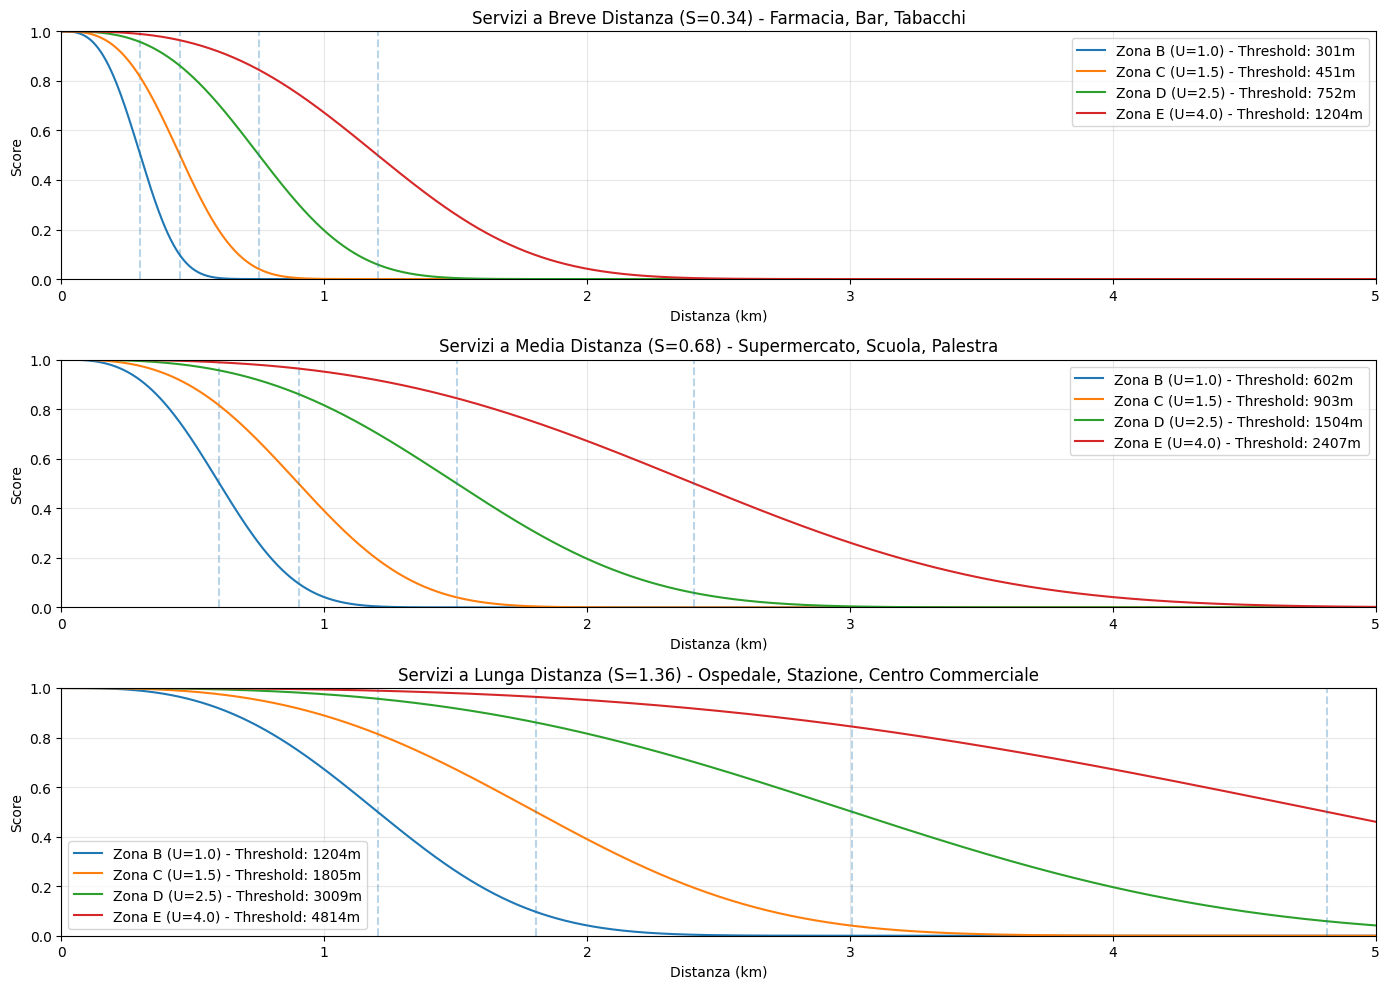


=== Distanze Threshold (score = 0.5) ===
Tipologia | Zona | S (km) | U | Threshold (m)
-------------------------------------------------------
Breve    | B    | 0.340 | 1.0 |    301
Breve    | C    | 0.340 | 1.5 |    451
Breve    | D    | 0.340 | 2.5 |    752
Breve    | E    | 0.340 | 4.0 |   1204
Media    | B    | 0.680 | 1.0 |    602
Media    | C    | 0.680 | 1.5 |    903
Media    | D    | 0.680 | 2.5 |   1504
Media    | E    | 0.680 | 4.0 |   2407
Lunga    | B    | 1.360 | 1.0 |   1204
Lunga    | C    | 1.360 | 1.5 |   1805
Lunga    | D    | 1.360 | 2.5 |   3009
Lunga    | E    | 1.360 | 4.0 |   4814


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Visualizzazione delle curve di decadimento per la nuova formula
# f(x) = e^(-(x / (S * U))^3)

x = np.linspace(0, 5, 1000)  # Distanze in km da 0 a 5km

# Parametri per servizi a breve distanza (S=0.340)
S_breve = 0.340
plt.figure(figsize=(14, 10))

# Subplot 1: Breve distanza
plt.subplot(3, 1, 1)
for zona, U in [('B', 1.0), ('C', 1.5), ('D', 2.5), ('E', 4.0)]:
    y = np.exp(-((x / (S_breve * U)) ** 3))
    threshold = S_breve * U * (np.log(2) ** (1/3))
    plt.plot(x, y, label=f'Zona {zona} (U={U}) - Threshold: {threshold*1000:.0f}m')
    plt.axvline(threshold, linestyle='--', alpha=0.3)
plt.xlabel('Distanza (km)')
plt.ylabel('Score')
plt.title('Servizi a Breve Distanza (S=0.34) - Farmacia, Bar, Tabacchi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)
plt.ylim(0, 1)

# Subplot 2: Media distanza
plt.subplot(3, 1, 2)
S_medio = 0.680
for zona, U in [('B', 1.0), ('C', 1.5), ('D', 2.5), ('E', 4.0)]:
    y = np.exp(-((x / (S_medio * U)) ** 3))
    threshold = S_medio * U * (np.log(2) ** (1/3))
    plt.plot(x, y, label=f'Zona {zona} (U={U}) - Threshold: {threshold*1000:.0f}m')
    plt.axvline(threshold, linestyle='--', alpha=0.3)
plt.xlabel('Distanza (km)')
plt.ylabel('Score')
plt.title('Servizi a Media Distanza (S=0.68) - Supermercato, Scuola, Palestra')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)
plt.ylim(0, 1)

# Subplot 3: Lunga distanza
plt.subplot(3, 1, 3)
S_lungo = 1.360
for zona, U in [('B', 1.0), ('C', 1.5), ('D', 2.5), ('E', 4.0)]:
    y = np.exp(-((x / (S_lungo * U)) ** 3))
    threshold = S_lungo * U * (np.log(2) ** (1/3))
    plt.plot(x, y, label=f'Zona {zona} (U={U}) - Threshold: {threshold*1000:.0f}m')
    plt.axvline(threshold, linestyle='--', alpha=0.3)
plt.xlabel('Distanza (km)')
plt.ylabel('Score')
plt.title('Servizi a Lunga Distanza (S=1.36) - Ospedale, Stazione, Centro Commerciale')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 5)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# Stampa i threshold esatti per verifica
print("\n=== Distanze Threshold (score = 0.5) ===")
print("Tipologia | Zona | S (km) | U | Threshold (m)")
print("-" * 55)
for tipo, S in [('Breve', 0.340), ('Media', 0.680), ('Lunga', 1.360)]:
    for zona, U in [('B', 1.0), ('C', 1.5), ('D', 2.5), ('E', 4.0)]:
        threshold = S * U * (np.log(2) ** (1/3))
        print(f"{tipo:8} | {zona:4} | {S:5.3f} | {U:3.1f} | {threshold*1000:6.0f}")

## Merge con Dataset Immobili

Merge dei percentili con il dataset principale degli immobili.

In [12]:
def merge_percentiles_with_immobili(
    percentiles_parquet_path='immobili_avg_scores_by_category.parquet',
    immobili_parquet_path='../../data/FOLDER_META/immobili_with_meta_and_ape_full_cleaned.parquet',
    output_parquet_path='../../data/FOLDER_META/immobili_with_meta_and_ape_full_cleaned.parquet'
):
    """
    Merge dei percentili calcolati con il dataset principale degli immobili.
    Sostituisce le colonne sanita, mobilita, verde, sport, commerciale, educazione
    con i nuovi percentili calcolati.
    
    Args:
        percentiles_parquet_path: Path al Parquet con i percentili per categoria
        immobili_parquet_path: Path al parquet degli immobili
        output_parquet_path: Path dove salvare il parquet aggiornato
    """
    print("=== Merge percentili con dataset immobili ===\n")
    
    # 1. Carica il Parquet dei percentili
    print(f"Caricamento percentili da: {percentiles_parquet_path}")
    percentiles_df = pd.read_parquet(percentiles_parquet_path)
    print(f"  - Righe: {len(percentiles_df)}")
    print(f"  - Categorie: {sorted(percentiles_df['category'].unique())}")
    
    # 2. Pivot per avere una riga per immobile con una colonna per ogni categoria
    print("\nPivot dei percentili...")
    percentiles_pivot = percentiles_df.pivot(
        index='immobile_id',
        columns='category',
        values='percentile'
    ).reset_index()
    
    # Mapping categorie con accenti -> senza accenti per le colonne del parquet
    category_mapping = {
        'sanità': 'sanita',
        'mobilità': 'mobilita',
        'verde': 'verde',
        'sport': 'sport',
        'commerciale': 'commerciale',
        'educazione': 'educazione'
    }
    
    # Rinomina le colonne rimuovendo gli accenti
    percentiles_pivot = percentiles_pivot.rename(columns=category_mapping)
    
    print(f"  - Shape pivot: {percentiles_pivot.shape}")
    print(f"  - Colonne: {percentiles_pivot.columns.tolist()}")
    
    # 3. Carica il parquet degli immobili
    print(f"\nCaricamento immobili da: {immobili_parquet_path}")
    immobili_df = pd.read_parquet(immobili_parquet_path)
    print(f"  - Righe: {len(immobili_df)}")
    print(f"  - Colonne originali: {immobili_df.shape[1]}")
    
    # Verifica che le colonne da sostituire esistano
    columns_to_replace = ['sanita', 'mobilita', 'verde', 'sport', 'commerciale', 'educazione']
    existing_cols = [col for col in columns_to_replace if col in immobili_df.columns]
    print(f"  - Colonne da sostituire presenti: {existing_cols}")
    
    # 4. Rimuovi le vecchie colonne di score
    print("\nRimozione vecchie colonne...")
    immobili_df = immobili_df.drop(columns=existing_cols, errors='ignore')
    print(f"  - Colonne dopo rimozione: {immobili_df.shape[1]}")
    
    # 5. Merge con i nuovi percentili
    print("\nMerge con i nuovi percentili...")
    immobili_updated = immobili_df.merge(
        percentiles_pivot,
        left_on='id',
        right_on='immobile_id',
        how='left'
    )
    
    # Rimuovi la colonna immobile_id duplicata
    if 'immobile_id' in immobili_updated.columns:
        immobili_updated = immobili_updated.drop(columns=['immobile_id'])
    
    print(f"  - Shape dopo merge: {immobili_updated.shape}")
    
    # 6. Verifica risultati
    print("\nVerifica risultati:")
    for col in columns_to_replace:
        if col in immobili_updated.columns:
            non_null = immobili_updated[col].notna().sum()
            print(f"  - {col}: {non_null}/{len(immobili_updated)} valori non-null")
            print(f"    Min: {immobili_updated[col].min():.2f}, Max: {immobili_updated[col].max():.2f}, Mean: {immobili_updated[col].mean():.2f}")
    
    # 7. Salva il parquet aggiornato
    print(f"\nSalvataggio in: {output_parquet_path}")
    immobili_updated.to_parquet(output_parquet_path, index=False)
    print("✓ Salvato con successo!")
    
    return immobili_updated

# Esegui il merge
result_df = merge_percentiles_with_immobili()

=== Merge percentili con dataset immobili ===

Caricamento percentili da: immobili_avg_scores_by_category.parquet
  - Righe: 89256
  - Categorie: ['commerciale', 'educazione', 'mobilità', 'sanità', 'sport', 'verde']

Pivot dei percentili...
  - Shape pivot: (14876, 7)
  - Colonne: ['immobile_id', 'commerciale', 'educazione', 'mobilita', 'sanita', 'sport', 'verde']

Caricamento immobili da: ../../data/FOLDER_META/immobili_with_meta_and_ape_full_cleaned.parquet
  - Righe: 14877
  - Colonne originali: 41
  - Colonne da sostituire presenti: ['sanita', 'mobilita', 'verde', 'sport', 'commerciale', 'educazione']

Rimozione vecchie colonne...
  - Colonne dopo rimozione: 35

Merge con i nuovi percentili...
  - Shape dopo merge: (14877, 41)

Verifica risultati:
  - sanita: 14877/14877 valori non-null
    Min: 0.01, Max: 100.00, Mean: 50.00
  - mobilita: 14877/14877 valori non-null
    Min: 0.01, Max: 100.00, Mean: 50.00
  - verde: 14877/14877 valori non-null
    Min: 0.01, Max: 99.99, Mean: 50.0

In [14]:
os.remove("immobili_amenity_scores_aggregated.csv")
os.remove("immobili_avg_scores_by_category.csv")